# Stile dei grafici

Questo notebook mostra come usare lo stile `mespy` in modo globale o per singola chiamata, e come sovrascrivere i parametri estetici principali di `mp.histogram` e `mp.lin_fit`.

## Import

In [1]:
import matplotlib.pyplot as plt

import mespy as mp


df_hist = mp.load_csv("data/test_misure.csv")
lunghezza = df_hist["lunghezza_mm"]

df_fit = mp.load_csv(
    "data/test_linear_fit.csv",
    required_columns=[
        "tempo_s",
        "spazio_m",
        "sigma_spazio_m",
        "sigma_tempo_s",
    ],
    missing="error",
)

tempo = df_fit["tempo_s"]
spazio = df_fit["spazio_m"]
sigma_spazio = df_fit["sigma_spazio_m"]
sigma_tempo = df_fit["sigma_tempo_s"]


## Stile globale `mespy`

Dopo `import mespy`, lo stile del package e registrato in Matplotlib e puo essere attivato anche a livello globale con `plt.style.use("mespy")`. In questo caso puoi passare `style=None` alle funzioni di `mespy` per usare gli `rcParams` gia attivi senza riapplicare uno stile locale.

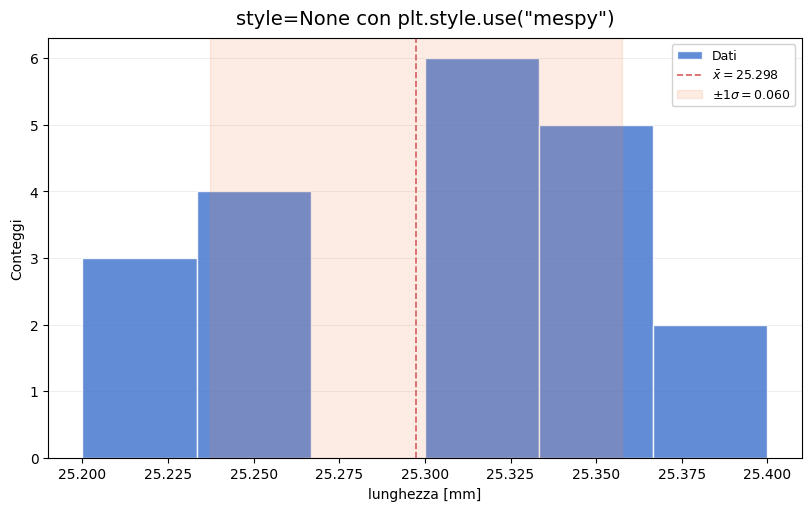

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'style=None con plt.style.use("mespy")'}, xlabel='lunghezza [mm]', ylabel='Conteggi'>)

In [2]:
plt.style.use("mespy")

mp.histogram(
    lunghezza,
    style=None,
    bins=6,
    xlabel="lunghezza [mm]",
    title='style=None con plt.style.use("mespy")',
    show_bin_ticks=False,
)


## Override mirati su `histogram`

I parametri estetici passati alla funzione sovrascrivono solo quella chiamata. Qui cambiamo colori, opacita, posizione della legenda e formattazione del titolo senza toccare il resto del notebook.

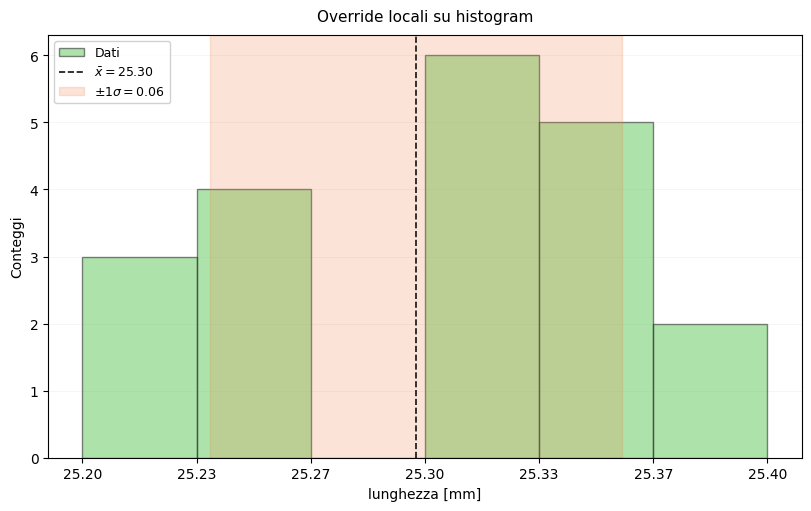

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Override locali su histogram'}, xlabel='lunghezza [mm]', ylabel='Conteggi'>)

In [3]:
mp.histogram(
    lunghezza,
    bins=6,
    style="mespy",
    xlabel="lunghezza [mm]",
    title="Override locali su histogram",
    title_fontsize=11,
    legend_loc="upper left",
    bar_color="#6ACC64",
    edgecolor="#1F1F1F",
    mean_color="#111111",
    band_color="#EE854A",
    hist_alpha=0.55,
    band_alpha=0.22,
    grid_alpha=0.18,
    decimals=2,
)


## Override mirati su `lin_fit`

Lo stesso schema vale per `lin_fit`: alcuni parametri possono essere lasciati allo stile attivo, altri possono essere ridefiniti solo per il grafico corrente.

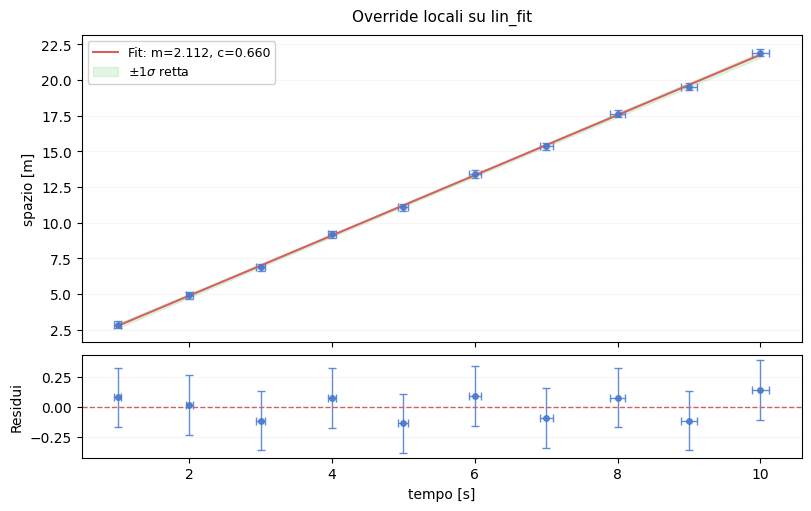

{'slope': 2.112, 'intercept': 0.66, 'iterations': 4, 'converged': True}

In [4]:
fit_style = mp.lin_fit(
    tempo,
    spazio,
    sigma_spazio,
    sigma_x=sigma_tempo,
    style="mespy",
    xlabel="tempo [s]",
    ylabel="spazio [m]",
    title="Override locali su lin_fit",
    title_fontsize=11,
    legend_loc="upper left",
    point_color="#4878CF",
    fit_color="#D65F5F",
    band_color="#6ACC64",
    data_alpha=0.85,
    band_alpha=0.18,
    grid_alpha=0.18,
    show_fit_params=True,
)

{
    "slope": round(fit_style.slope, 3),
    "intercept": round(fit_style.intercept, 3),
    "iterations": fit_style.iterations,
    "converged": fit_style.converged,
}


## Pagine collegate

- [`histogram`](../moduli/plot_utils/histogram.md)
- [`lin_fit`](../moduli/fit_utils/lin-fit.md)
- [`_style_context`](../checks/plot_utils/style-context.md)
- [`_validate_decimals`](../checks/plot_utils/validate-decimals.md)
